Outlook {'Overcast': np.int64(0), 'Rainy': np.int64(1), 'Sunny': np.int64(2)}
Temperature {'Cool': np.int64(0), 'Hot': np.int64(1), 'Mild': np.int64(2)}
Humidity {'High': np.int64(0), 'Normal': np.int64(1)}
Windy {np.False_: np.int64(0), np.True_: np.int64(1)}
PlayTennis {'No': np.int64(0), 'Yes': np.int64(1)}
Gini tree — CV accuracy: 0.70 (+/- 0.16)
Entropy tree — CV accuracy: 0.63 (+/- 0.07)
Confusion Matrix for Gini tree:
[[5 0]
 [0 9]]
Classification Report for Gini tree:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         9

    accuracy                           1.00        14
   macro avg       1.00      1.00      1.00        14
weighted avg       1.00      1.00      1.00        14

Confusion Matrix for Entropy tree:
[[5 0]
 [0 9]]
Classification Report for Entropy tree:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    

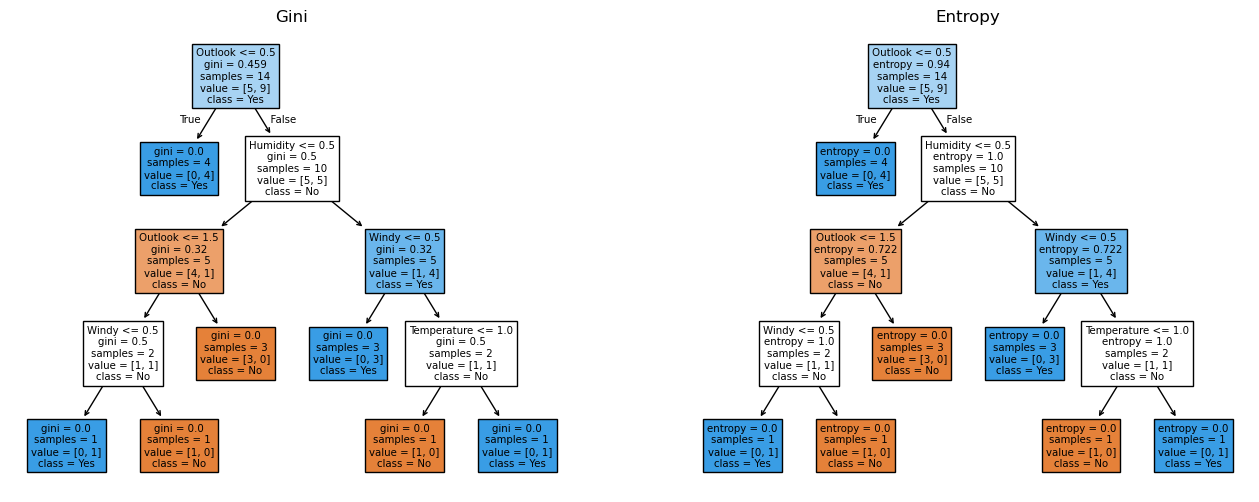

Gini new sample tree prediction: No
Entropy new sample tree prediction: No
Model saved to playtennis_dt_gini.joblib
Prediction: No


In [8]:
# load the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import sklearn.tree as tree
import sklearn.metrics as metrics
import sklearn.model_selection as model_selection


#load the dataset
df = pd.read_csv("D:/DSD/GUC/GUC Data Science Diploma/Machine learning/Supervised learning/Decision tree/DT_df.csv")


# Convert text to numbers
# In scikit-learn's LabelEncoder, it looks at each column, finds its unique values, sorts them alphabetically, and assigns 0, 1, 2, ... in that order. For example: Outlook → Overcast=0, Rainy=1, Sunny=2; Windy → False=0, True=1; PlayTennis → No=0, Yes=1

from sklearn.preprocessing import LabelEncoder

encoders = {}
df_encoded = df.copy()

for col in df_encoded.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    encoders[col] = le
    print(col, dict(zip(le.classes_, le.transform(le.classes_))))

# Split the data into features and target variable
X = df_encoded.drop('PlayTennis', axis=1)
y = df_encoded['PlayTennis']    
    

# Split the data into training and testing sets
#from sklearn.model_selection import train_test_split

#X_train, X_test, y_train, y_test = train_test_split(
#    X, y,
#    test_size=0.3,      # 30% held out for testing
#    random_state=42,
#    stratify=y          # preserve class balance in both splits
#)

#print("Train size:", X_train.shape[0])
#print("Test size:", X_test.shape[0])

# cross-validation is a better way to evaluate the model's performance, especially with small datasets. It splits the data into k folds, trains on k-1 folds, and tests on the remaining fold, repeating this process k times. The final performance metric is the average of the k test results.
from sklearn.model_selection import cross_val_score

for name, clf in [("Gini", DecisionTreeClassifier(criterion="gini", random_state=42)),
                   ("Entropy", DecisionTreeClassifier(criterion="entropy", random_state=42))]:
    scores = cross_val_score(clf, X, y, cv=5)  # 5-fold on the FULL dataset
    print(f"{name} tree — CV accuracy: {scores.mean():.2f} (+/- {scores.std():.2f})")





# Train the decision tree classifier using Gini Index 
from sklearn.tree import DecisionTreeClassifier

tree_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
tree_gini.fit(X, y) 

# Train the decision tree classifier using Entropy
tree_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)
tree_entropy.fit(X, y)



#Evaluate the models using confusion matrix and classification report
from sklearn.metrics import confusion_matrix, classification_report

for name, clf in [("Gini", tree_gini), ("Entropy", tree_entropy)]:
    preds = clf.predict(X)
    print(f"Confusion Matrix for {name} tree:")
    print(confusion_matrix(y, preds))
    print(f"Classification Report for {name} tree:")
    print(classification_report(y, preds))
    
# visualize the decision trees 
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_tree(tree_gini, feature_names=X.columns, class_names=encoders["PlayTennis"].classes_,
          filled=True, ax=axes[0])
axes[0].set_title("Gini")
plot_tree(tree_entropy, feature_names=X.columns, class_names=encoders["PlayTennis"].classes_,
          filled=True, ax=axes[1])
axes[1].set_title("Entropy")
plt.show()

# Classify new sample using the trained decision tree classifiers

new_sample = {
    "Outlook": "Sunny",
    "Temperature": "Cool",
    "Humidity": "High",
    "Windy": "True"
}

# convert the new sample to a DataFrame and encode it using the same encoders
new_encoded = [[encoders[col].transform([new_sample[col]])[0] for col in X.columns]]
new_df = pd.DataFrame(new_encoded, columns=X.columns)

for name, clf in [("Gini", tree_gini), ("Entropy", tree_entropy)]:
    pred = clf.predict(new_df)
    label = encoders["PlayTennis"].inverse_transform(pred)
    print(f"{name} new sample tree prediction: {label[0]}")

# Save the model and encoders for deployment
import joblib
# Pick whichever tree you want to deploy (or save both)
deployment_package = {
    "model": tree_gini,                # or tree_entropy
    "encoders": encoders,              # needed to encode new inputs & decode predictions
    "feature_columns": list(X.columns) # needed to build the input in the right order
}

joblib.dump(deployment_package, "playtennis_dt_gini.joblib")
print("Model saved to playtennis_dt_gini.joblib")

#Load the model back and use it (this is what your deployment/serving code would run)

#This simulates what happens in production: load the saved file once, then use it to predict on any new incoming sample without needing the original training script at all.


import joblib
import pandas as pd

# Load once when the service starts
package = joblib.load("playtennis_dt_gini.joblib")
model = package["model"]
encoders = package["encoders"]
feature_columns = package["feature_columns"]

def predict_play_tennis(sample: dict) -> str:
    """sample e.g. {'Outlook': 'Sunny', 'Temperature': 'Cool', 'Humidity': 'High', 'Windy': 'True'}"""
    encoded_row = [[encoders[col].transform([sample[col]])[0] for col in feature_columns]]
    input_df = pd.DataFrame(encoded_row, columns=feature_columns)
    pred = model.predict(input_df)
    return encoders["PlayTennis"].inverse_transform(pred)[0]

# Example usage
result = predict_play_tennis({"Outlook": "Sunny", "Temperature": "Cool", "Humidity": "High", "Windy": "True"})
print("Prediction:", result)   